## Settings

In [129]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from DataTransformation import LowPassFilter, PrincipalComponentAnalysis
from TemporalAbstraction import NumericalAbstraction
from FrequencyAbstraction import FourierTransformation
from sklearn.cluster import KMeans

In [24]:
os.chdir('c:\\Users\\SK\\Desktop\\Sensor_data_analysis\\src\\features')

In [25]:
%matplotlib inline
# plt.style.available
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['lines.linewidth'] = 2

## Load data

In [26]:
df = pd.read_pickle('../../data/interim/02_chauvenet_outliers_processed.pkl')
df.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set
epoch (ms),,,,,,,,,,
2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30
2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30
2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30
2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30
2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30


In [27]:
predictor_cols = list(df.columns[:6])
predictor_cols

['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

## Impute missing values

Outliers were transformed into missing values (NaN) in the previous session. 

In [28]:
# Before imputation
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   acc_x        9005 non-null   float64
 1   acc_y        8998 non-null   float64
 2   acc_z        8999 non-null   float64
 3   gyro_x       8984 non-null   float64
 4   gyro_y       8938 non-null   float64
 5   gyro_z       8945 non-null   float64
 6   participant  9009 non-null   str    
 7   label        9009 non-null   str    
 8   category     9009 non-null   str    
 9   set          9009 non-null   int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 774.2 KB


In [29]:
# After imputation - no null values
for col in predictor_cols:
    df[col] = df[col].interpolate('linear')
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   acc_x        9009 non-null   float64
 1   acc_y        9009 non-null   float64
 2   acc_z        9009 non-null   float64
 3   gyro_x       9009 non-null   float64
 4   gyro_y       9009 non-null   float64
 5   gyro_z       9009 non-null   float64
 6   participant  9009 non-null   str    
 7   label        9009 non-null   str    
 8   category     9009 non-null   str    
 9   set          9009 non-null   int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 774.2 KB


## Calculate each set duration
* Heavy set: 5 repetition
* Medium set: 10 repetition

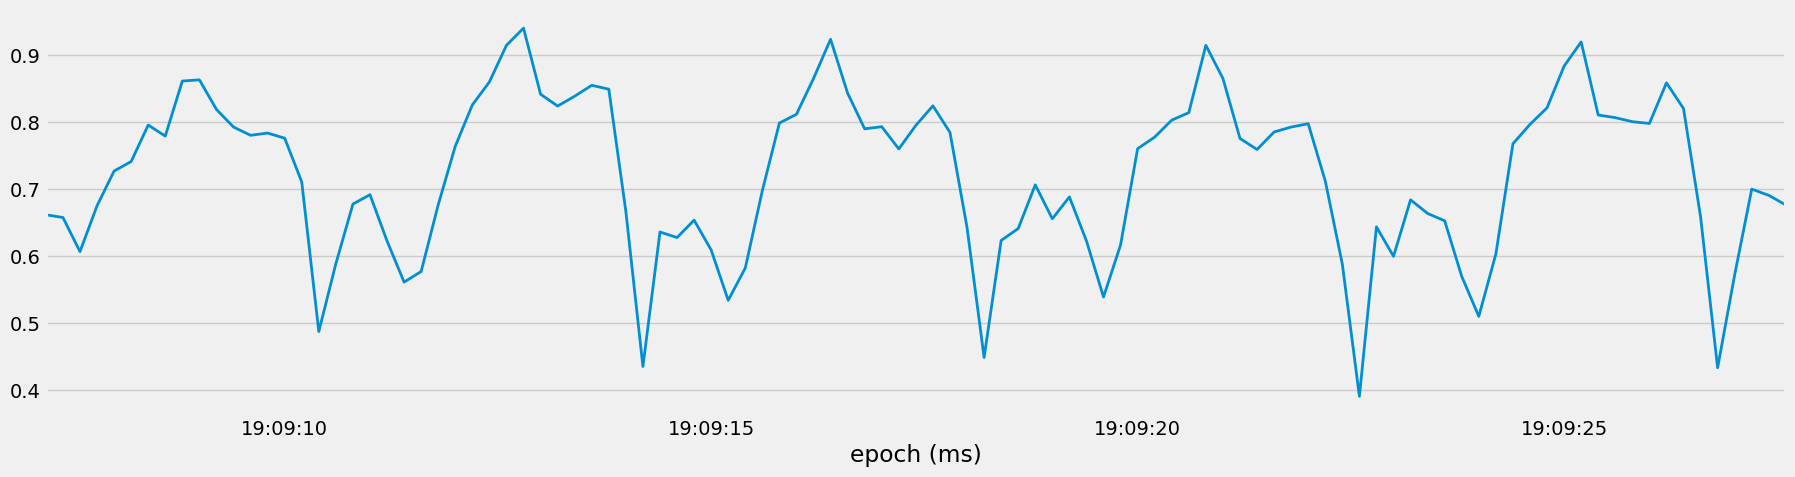

In [30]:
df.loc[df['set']==25, 'acc_z'].plot()    # Heavy set
plt.show()

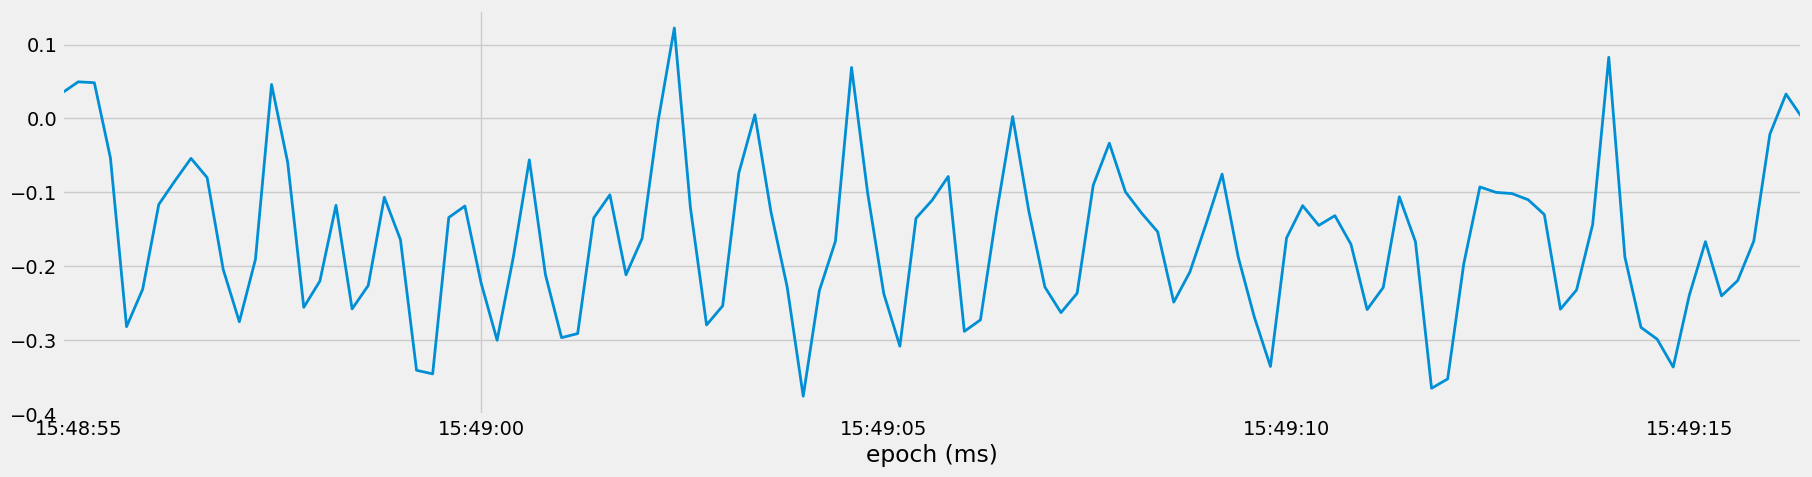

In [31]:
df.loc[df['set']==35, 'acc_z'].plot()     # Medium set
plt.show()

> NOTE: In the signal data, there are many small curves. The objective of this session is to remove those fluctuations to see the big outline patterns.

In [32]:
duration = df[df['set']==1].index[-1] - df[df['set']==1].index[0]
duration.seconds    

16

In [33]:
# Loop over all sets
for set in df['set'].unique():
    duration = df[df['set']==set].index[-1] - df[df['set']==set].index[0]
    # Add a duration column to dataframe
    df.loc[df['set']==set, 'duration'] = duration.seconds

df.tail()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,duration
epoch (ms),,,,,,,,,,,
2019-01-20 17:33:27.000,-0.048000,-1.041500,-0.076500,1.4146,-5.6218,0.2926,E,row,medium,90,19.0
2019-01-20 17:33:27.200,-0.037000,-1.030333,-0.053333,-2.7684,-0.5854,2.2440,E,row,medium,90,19.0
2019-01-20 17:33:27.400,-0.060000,-1.031000,-0.082000,2.8416,-5.1342,-0.1220,E,row,medium,90,19.0
2019-01-20 17:33:27.600,-0.038667,-1.025667,-0.044667,-0.2318,0.2562,1.1220,E,row,medium,90,19.0
2019-01-20 17:33:27.800,-0.044000,-1.034000,-0.059000,1.0980,-4.0240,0.9760,E,row,medium,90,19.0


In [34]:
duration_df = df.groupby(['category'])['duration'].mean()
duration_df

category
heavy       14.743501
medium      24.942529
sitting     33.000000
standing    39.000000
Name: duration, dtype: float64

### Calculate each repetition duration

This information will be used for the window size in Discrete Fourier Transformation later.

In [35]:
print('One heavy rep duration:', duration_df.iloc[0] / 5)    
print('One medium rep duration:', duration_df.iloc[1] / 10)   

One heavy rep duration: 2.9487001733102254
One medium rep duration: 2.4942528735632186


## 1. Butterworth Lowpass Filter

A Butterworth low-pass filter is a type of filter that is used to remove high frequency noise from a dataset. It is most commonly used in machine learning in order to improve the accuracy of the model. The filter works by **removing any data points above a certain threshold frequency, while still preserving the underlying pattern** of the data. By doing so, it helps to reduce the effect of noise on the model, which can lead to better results.

In [36]:
df_lowpass = df.copy()
LowPass = LowPassFilter()

# Parameters for low-pass filter
fs = 1000 / 200   # Sampling frequency(Hz): 1000 ms / 200 ms
cutoff = 1.3      # The higher cutoff frequency, the less smoothing effect

df_lowpass = LowPass.low_pass_filter(df_lowpass, 'acc_y', fs, cutoff, order=5)
df_lowpass

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,duration,acc_y_lowpass
epoch (ms),,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30,16.0,0.977003
2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30,16.0,0.973169
2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30,16.0,0.966879
2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30,16.0,0.962244
2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30,16.0,0.959572
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.048000,-1.041500,-0.076500,1.4146,-5.6218,0.2926,E,row,medium,90,19.0,-0.988153
2019-01-20 17:33:27.200,-0.037000,-1.030333,-0.053333,-2.7684,-0.5854,2.2440,E,row,medium,90,19.0,-1.053448
2019-01-20 17:33:27.400,-0.060000,-1.031000,-0.082000,2.8416,-5.1342,-0.1220,E,row,medium,90,19.0,-1.044737


### Visualisation before and aftr the filter

It shows smoothened data after applying the filter, maintaining the original pattern. Adjust cutoff frequency to find the best value for the data.

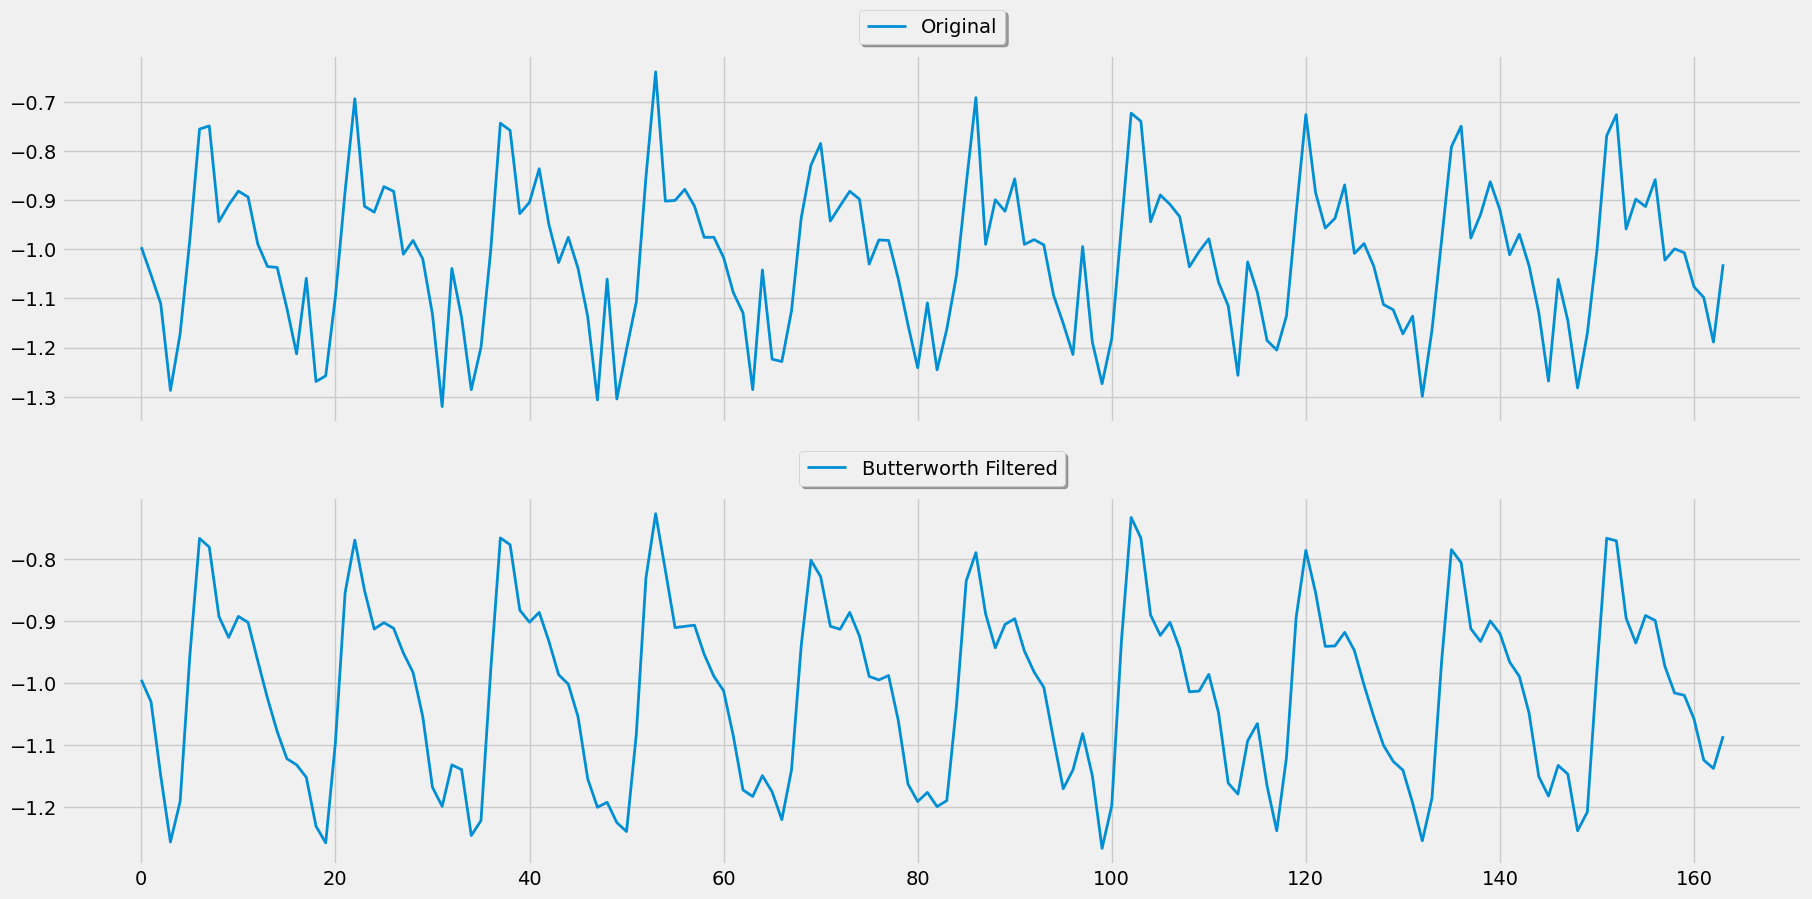

In [37]:
df_subset = df_lowpass[df_lowpass['set']==42]

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))
ax[0].plot(df_subset['acc_y'].reset_index(drop=True), label='Original')
ax[1].plot(df_subset['acc_y_lowpass'].reset_index(drop=True), label='Butterworth Filtered')
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True) 
plt.show()

### Apply the filter to all columns

In [38]:
df_lowpass = df.copy()

for col in predictor_cols:
    df_lowpass = LowPass.low_pass_filter(df_lowpass, col, fs, cutoff, order=5)
    df_lowpass[col] = df_lowpass[col + '_lowpass']
    del df_lowpass[col + '_lowpass']

df_lowpass

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,duration
epoch (ms),,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,30,16.0
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,30,16.0
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,30,16.0
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,30,16.0
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,30,16.0
...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,90,19.0
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,90,19.0
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,90,19.0


## 2. Principal Component Analysis (PCA)

PCA fundamentally works by **rotating the original axes into a new set of axes (the principal components)** that better capture the directions of maximum variance in the data. When all components are kept, the number of axes stays the same as the original number of features; no dimensionality reduction occurs, just a reorientation of the coordinate system. **Dimensionality reduction happens only when a subset of these components is selected**, specifically those that explain the most variance, while the remaining low-variance components are discarded.

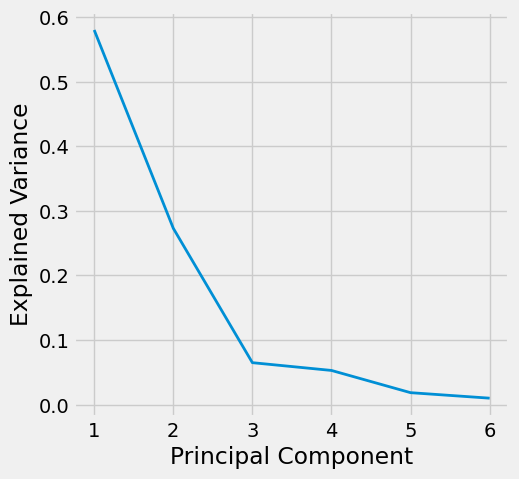

In [39]:
df_pca = df_lowpass.copy()

PCA = PrincipalComponentAnalysis()
# Calculate the explained variance for all principal components
pc_variances = PCA.determine_pc_explained_variance(df_pca, predictor_cols)
# sum(pc_variances)     # Total variance explained by all principal components should be 1.0

# Plot the explained variance to find the elbow
plt.figure(figsize=(5, 5))
plt.plot(range(1, len(predictor_cols) + 1), pc_variances)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()

> NOTE: According to the elbow technique, select the point at which the rate of change in variance diminishes sharply. Thus, we will pick **3 components** for analysis.

In [40]:
# PCA with 3 principal components
df_pca = PCA.apply_pca(df_pca, predictor_cols, number_comp=3)
df_pca

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,duration,pca_1,pca_2,pca_3
epoch (ms),,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,30,16.0,0.315889,-0.075461,0.072243
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,30,16.0,0.314873,-0.073888,0.069825
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,30,16.0,0.314236,-0.080343,0.066219
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,30,16.0,0.314356,-0.090852,0.061839
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,30,16.0,0.313630,-0.097479,0.062974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,90,19.0,-0.349351,-0.148450,-0.053031
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,90,19.0,-0.371610,-0.151455,-0.058498
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,90,19.0,-0.368098,-0.153153,-0.058772


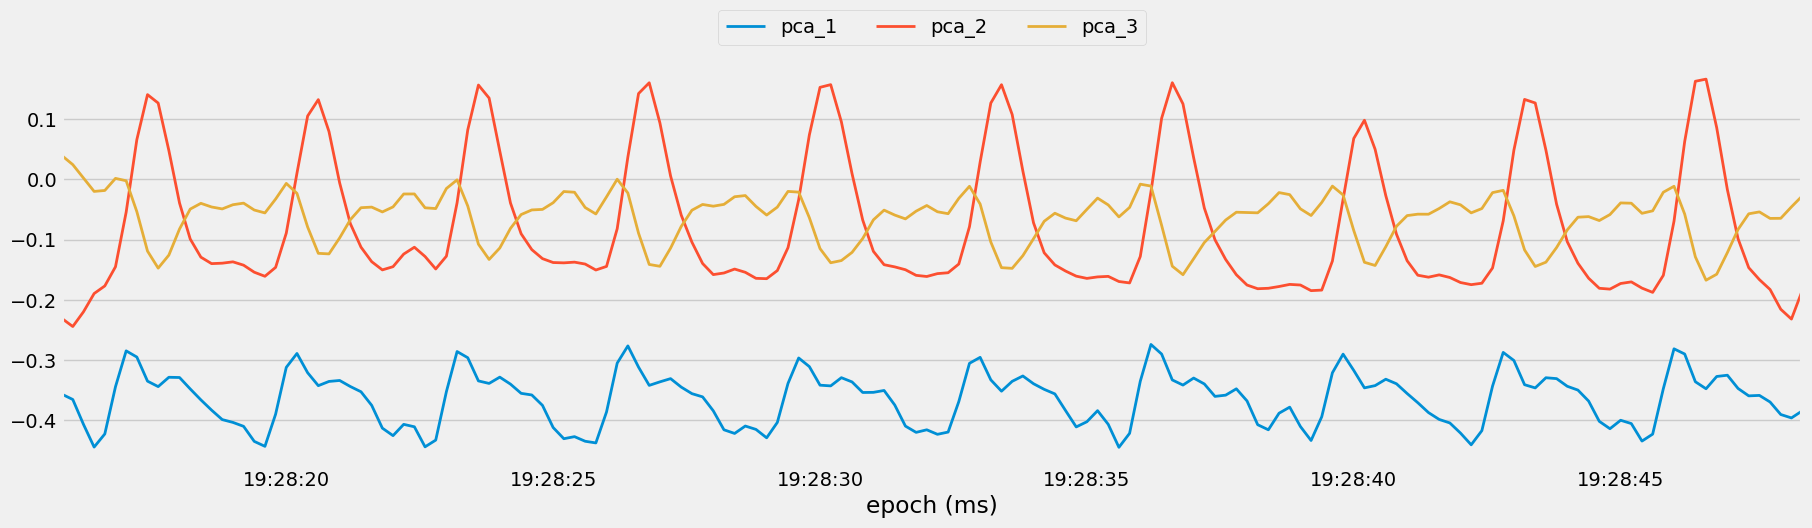

In [41]:
# Subset visualisation
df_subset = df_pca[df_pca['set']==42]
df_subset[['pca_1', 'pca_2', 'pca_3']].plot()
plt.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15))

## 3. Sum of squares of attributes

To further exploit the data, the scalar magnitudes `r` of the accelerometer and gyroscope were calculated. r is the scalar magnitude of the three combined data points: `x`, `y`, and `z`. The advantage of using r versus any particular data direction is that it is **impartial to device orientation and can handle dynamic re-orientations**. `r` is calculated by:

$ r_{magnitude} = \sqrt{x^2 + y^2 + z^2} $

In [42]:
df_square = df_pca.copy()

acc_r_square = df_square['acc_x']**2 + df_square['acc_y']**2 + df_square['acc_z']**2
gyro_r_square = df_square['gyro_x']**2 + df_square['gyro_y']**2 + df_square['gyro_z']**2
df_square['acc_r'] = np.sqrt(acc_r_square)
df_square['gyro_r'] = np.sqrt(gyro_r_square)
df_square.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,duration,pca_1,pca_2,pca_3,acc_r,gyro_r
epoch (ms),,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,30,16.0,0.315889,-0.075461,0.072243,0.979672,3.222503
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,30,16.0,0.314873,-0.073888,0.069825,0.975474,0.600176
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,30,16.0,0.314236,-0.080343,0.066219,0.969585,4.948974
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,30,16.0,0.314356,-0.090852,0.061839,0.966278,5.903203
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,30,16.0,0.313630,-0.097479,0.062974,0.964693,2.293593


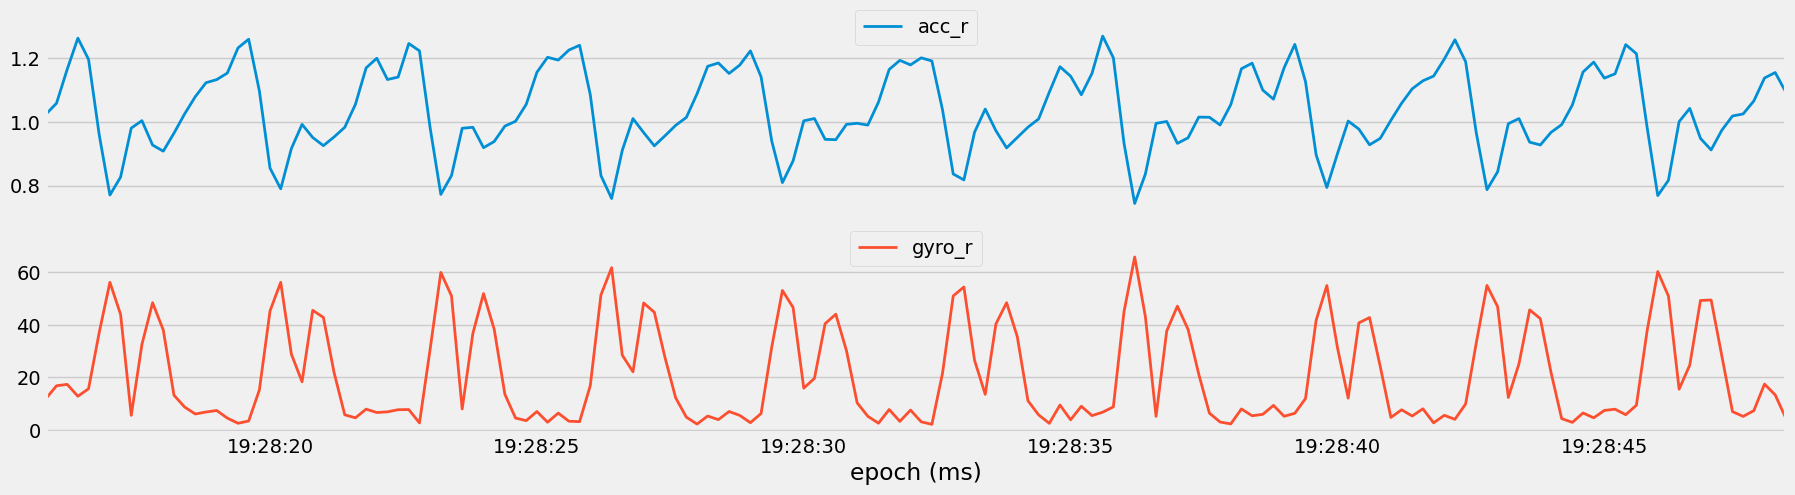

In [43]:
# Subset visualisation
df_subset = df_square[df_square['set']==42]
axes = df_subset[['acc_r', 'gyro_r']].plot(subplots=True)
for ax in axes:
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15))
plt.show()

## 4. Temporal abstraction

Numerical (or temporal) abstraction is the process of **converting raw, point-by-point sensor readings into higher-level summary features that capture patterns over time**. Instead of using each individual measurement directly, a rolling window of past values is aggregated—using statistics such as mean, median, standard deviation, max or min—into a single representative value at each time step. This shifts the data **from "what is the value right now" to "what has the recent trend looked like,"** which is often more informative for distinguishing between activities or detecting patterns in time-series data.

In [44]:
df_temporal = df_square.copy()

NumAbs = NumericalAbstraction()
predictor_columns = predictor_cols + ['acc_r', 'gyro_r']
window_size = int(1000 / 200)    # 1s / data frequency

# Don't do rolling window operations on the entire data, as each set is different exercise in different timeframe.
# Otherwise, the rolling window will be applied across sets, which is not what we want.
df_subset_list = []

for s in df_temporal['set'].unique():
    df_subset = df_temporal[df_temporal['set'] ==s].copy()
    df_subset = NumAbs.abstract_numerical(df_subset, predictor_columns, window_size, 'mean')
    df_subset = NumAbs.abstract_numerical(df_subset, predictor_columns, window_size, 'std')
    df_subset_list.append(df_subset)

df_temporal = pd.concat(df_subset_list)
df_temporal

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,acc_r_temp_mean_ws_5,gyro_r_temp_mean_ws_5,acc_x_temp_std_ws_5,acc_y_temp_std_ws_5,acc_z_temp_std_ws_5,gyro_x_temp_std_ws_5,gyro_y_temp_std_ws_5,gyro_z_temp_std_ws_5,acc_r_temp_std_ws_5,gyro_r_temp_std_ws_5
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,30,...,0.971141,3.393690,0.015436,0.006526,0.011110,2.602489,2.043684,0.971453,0.005643,1.884665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,90,...,1.084478,19.075515,0.042764,0.122536,0.076584,18.259425,5.430793,6.254808,0.121141,15.269147
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,90,...,1.103662,11.430679,0.026309,0.107114,0.021416,12.436925,3.656665,5.065650,0.106692,10.419379
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,90,...,1.061156,5.509310,0.008529,0.072055,0.017966,4.018501,1.189271,2.192982,0.072672,2.443328


> NOTE: For the newly created columns after the rolling window (size=5) operation, the first 4 data points of each set have `NaN`.

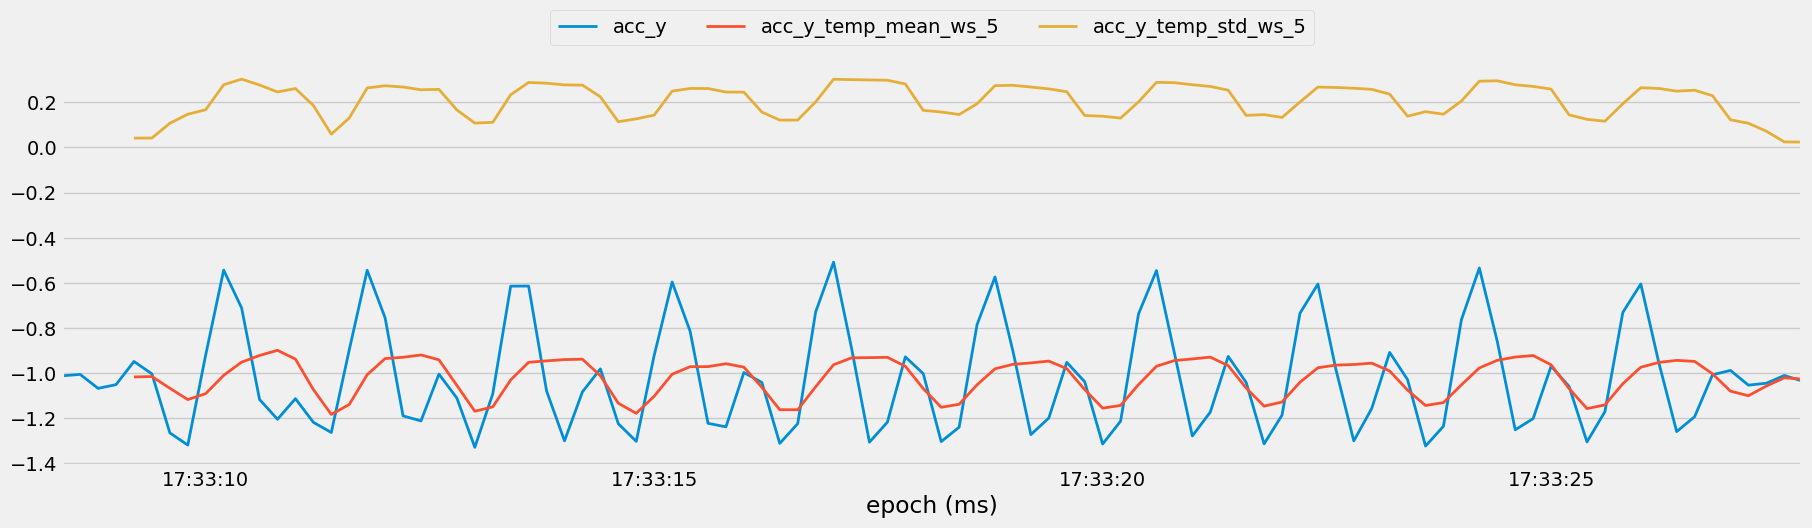

In [45]:
# Subset visualisation
df_subset[['acc_y', 'acc_y_temp_mean_ws_5', 'acc_y_temp_std_ws_5']].plot()
plt.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15))
plt.show()

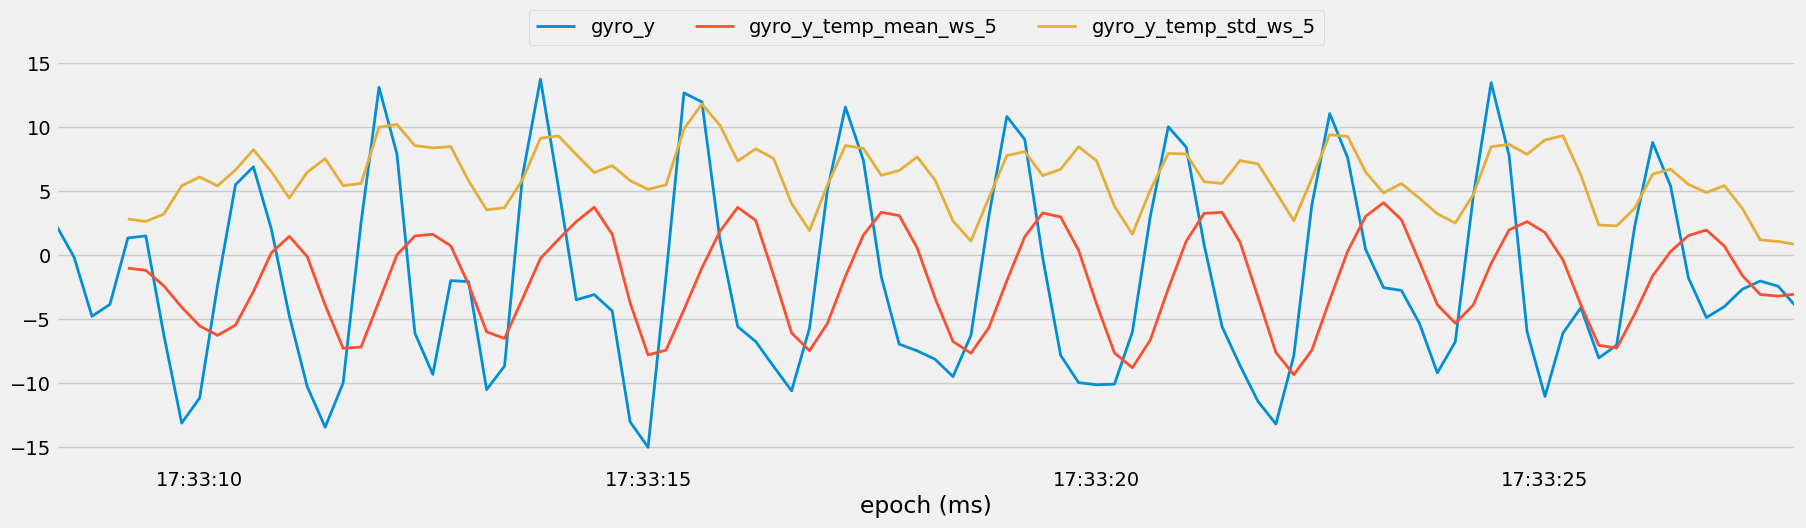

In [46]:
df_subset[['gyro_y', 'gyro_y_temp_mean_ws_5', 'gyro_y_temp_std_ws_5']].plot()
plt.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15))
plt.show()

## 5. Frequency abstraction - Discrete Fourier Transformation (DFT)

The idea of a Fourier transformation is that any sequence of measurements we perform can be represented by a **combination of sinusoid functions with different frequencies**.

A DFT is beneficial for Machine Learning, as it can be used to represent data in terms of frequency components, allowing for more efficient analysis of the data. This provides a way to better understand and model complex datasets, as the frequency components produced by the DFT can provide insight into patterns and trends that would not otherwise be visible. Additionally, the DFT can be used to reduce noise, allowing for more accurate models.

Features we will be extracting:

* Amplitude (for each of the relevant frequencies that are part of the time window)
* Max frequency
* Weighted frequency (average)
* Power spectral entropy

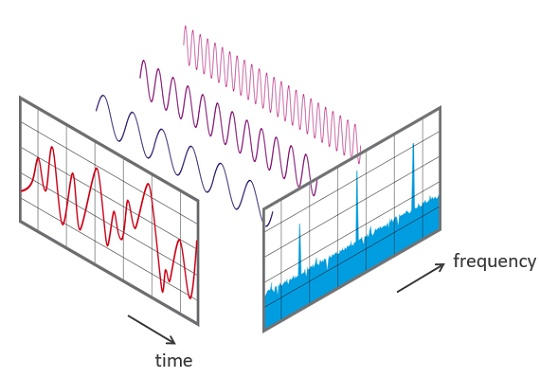

In [ ]:
# Numbered index is needed.
df_freq = df_temporal.copy().reset_index()
df_freq.head()

,epoch (ms),acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,...,acc_r_temp_mean_ws_5,gyro_r_temp_mean_ws_5,acc_x_temp_std_ws_5,acc_y_temp_std_ws_5,acc_z_temp_std_ws_5,gyro_x_temp_std_ws_5,gyro_y_temp_std_ws_5,gyro_z_temp_std_ws_5,acc_r_temp_std_ws_5,gyro_r_temp_std_ws_5
0,2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,...,0.971141,3.39369,0.015436,0.006526,0.01111,2.602489,2.043684,0.971453,0.005643,1.884665


### Apply to a column

If there are **n** data points, DFT decomposes the signal into exactly **n** frequency components; this ensures the original signal in time domain can be perfectly recomposed from the frequency domain. In the `FourierTransformation` class, `rfftfreq` returns the list of frequencies after decomposition, while `rfft` returns the amplitude of each frequency component as a complex number (real + imaginary part).

Since the input signal is real-valued, the DFT output has **conjugate symmetry**: for index `k` and index `N-k`, the values are complex conjugates of each other (same real part, opposite-sign imaginary part). This is to sum back to real number in recomposition. This means the second half of the output is fully determined by the first half, so `rfft` and `rfftfreq` only return the first half (**(n/2 + 1)** elements for even **n**, **(n + 1)/2** for odd **n**)).

Here, with a window size of 14, **(14/2) + 1 = 8** frequencies and their amplitudes are returned. In addition, three summary features are computed: **frequency with max amplitude, weighted average frequency, and Power Spectral Entropy (PSE)**, bringing the total 11 new columns added per a column.

In [48]:
FreqAbs = FourierTransformation()
fs = 1000 / 200   # Sampling frequency(Hz): 1000 ms / 200 ms
window_size = int(2900 / 200)   # Average length of one rep (ms) / 200 ms

# New 11 columns added for each column
df_freq = FreqAbs.abstract_frequency(df_freq, ['acc_y'], window_size, fs)
df_freq.head(15)

,epoch (ms),acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,...,acc_y_freq_weighted,acc_y_pse,acc_y_freq_0.0_Hz_ws_14,acc_y_freq_0.357_Hz_ws_14,acc_y_freq_0.714_Hz_ws_14,acc_y_freq_1.071_Hz_ws_14,acc_y_freq_1.429_Hz_ws_14,acc_y_freq_1.786_Hz_ws_14,acc_y_freq_2.143_Hz_ws_14,acc_y_freq_2.5_Hz_ws_14
0,2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-01-11 15:08:06.200,-0.021860,0.935017,-0.118288,6.239815,4.229132,-12.113541,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-01-11 15:08:06.400,-0.066640,0.866328,-0.168480,19.462687,7.891311,-24.117261,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019-01-11 15:08:06.600,-0.154064,0.813906,-0.222939,15.960932,4.373490,-18.659437,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2019-01-11 15:08:06.800,-0.221386,0.897218,-0.218732,-9.397740,-4.880007,2.885153,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2019-01-11 15:08:07.000,-0.221447,1.094101,-0.146658,-23.237111,-10.065368,13.681056,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


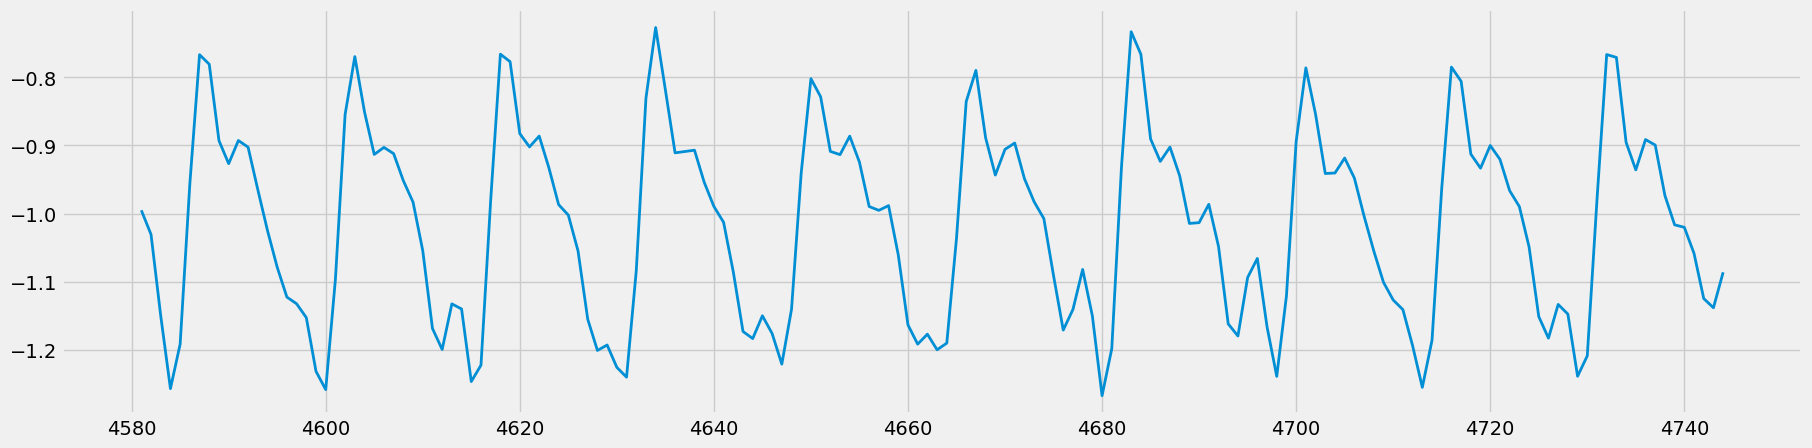

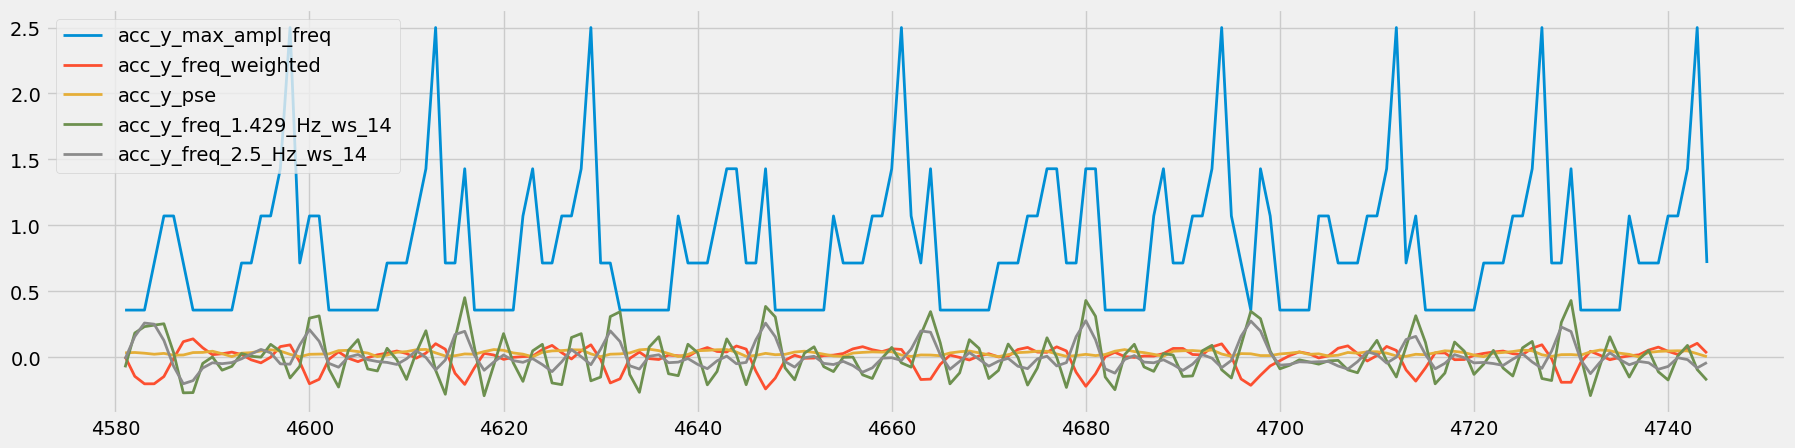

In [ ]:
# Subset visualisation
df_subset = df_freq[df_freq['set']==42]
df_subset['acc_y'].plot()
df_subset[
    [
        'acc_y_max_ampl_freq', 
        'acc_y_freq_weighted',
        'acc_y_pse', 
        'acc_y_freq_1.429_Hz_ws_14', 
        'acc_y_freq_2.5_Hz_ws_14'
    ]
].plot()
plt.show()

### Apply to all columns

New 11 columns/column * 8 predictor_columns = Total new 88 columns added.

In [117]:
df_freq = df_temporal.copy()

df_subset_list = []

for s in df_freq['set'].unique():
    df_subset = df_freq[df_freq['set']==s].reset_index().copy()
    df_subset = FreqAbs.abstract_frequency(df_subset, predictor_columns, window_size, fs)
    df_subset_list.append(df_subset)

df_freq = pd.concat(df_subset_list).set_index('epoch (ms)')
df_freq

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_r_freq_weighted,gyro_r_pse,gyro_r_freq_0.0_Hz_ws_14,gyro_r_freq_0.357_Hz_ws_14,gyro_r_freq_0.714_Hz_ws_14,gyro_r_freq_1.071_Hz_ws_14,gyro_r_freq_1.429_Hz_ws_14,gyro_r_freq_1.786_Hz_ws_14,gyro_r_freq_2.143_Hz_ws_14,gyro_r_freq_2.5_Hz_ws_14
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,90,...,0.517295,0.458224,304.102002,-34.618025,51.107043,70.397192,7.962594,20.975913,26.586397,12.929543
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,90,...,0.618644,0.689192,265.401659,-70.414292,32.966656,60.287966,-19.397682,49.008049,16.646854,25.770801
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,90,...,0.052287,0.542836,237.062115,-79.096849,11.032631,-11.172322,45.676671,-25.718191,7.650398,2.568743


## Dealing with overlapping windows

After rolling window operations, each data point is highly correlated to the neighboring points, which could result in overfitting. We will select only 50% of data by picking every other row. If the dataset is small, we can adjust the percentage to keep more data.

In [126]:
# Drop NaNs made from rolling window operations
df_freq = df_freq.dropna()
df_freq

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_r_freq_weighted,gyro_r_pse,gyro_r_freq_0.0_Hz_ws_14,gyro_r_freq_0.357_Hz_ws_14,gyro_r_freq_0.714_Hz_ws_14,gyro_r_freq_1.071_Hz_ws_14,gyro_r_freq_1.429_Hz_ws_14,gyro_r_freq_1.786_Hz_ws_14,gyro_r_freq_2.143_Hz_ws_14,gyro_r_freq_2.5_Hz_ws_14
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:07.800,-0.230583,0.920658,-0.227095,-10.707472,-5.021034,15.580872,B,bench,heavy,30,...,-1.248862,0.575207,202.086051,-47.005987,14.461290,-27.989176,-21.905348,20.370726,4.973285,-42.780588
2019-01-11 15:08:08.000,-0.172350,0.909033,-0.168556,-27.895242,-10.831760,26.285743,B,bench,heavy,30,...,-1.337543,0.373042,238.693334,-30.107267,-0.331527,10.360498,-25.776015,-19.652640,-52.725140,6.173306
2019-01-11 15:08:08.200,-0.075541,0.854894,-0.094507,-17.787623,-7.152388,16.679304,B,bench,heavy,30,...,-0.932848,0.402857,263.504875,-21.498290,-36.012237,1.513836,-8.751616,-47.941311,31.072425,-30.984847
2019-01-11 15:08:08.400,-0.024777,0.860474,-0.059254,-2.040040,-1.316930,1.986210,B,bench,heavy,30,...,0.170579,0.665444,261.692953,-35.075339,-70.516254,-34.901509,5.262501,55.752651,-26.444490,32.796769
2019-01-11 15:08:08.600,-0.039468,0.947898,-0.047164,1.731909,-0.126808,-3.356740,B,bench,heavy,30,...,-0.936061,0.426478,259.569075,-41.806914,-51.432388,-15.707154,8.694112,-18.444969,20.304371,-30.672891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,90,...,0.517295,0.458224,304.102002,-34.618025,51.107043,70.397192,7.962594,20.975913,26.586397,12.929543
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,90,...,0.618644,0.689192,265.401659,-70.414292,32.966656,60.287966,-19.397682,49.008049,16.646854,25.770801
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,90,...,0.052287,0.542836,237.062115,-79.096849,11.032631,-11.172322,45.676671,-25.718191,7.650398,2.568743


In [128]:
# Select only 50% of data by picking every other row. Sampling interval becomes 400ms.
df_freq = df_freq.iloc[::2]
df_freq

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_r_freq_weighted,gyro_r_pse,gyro_r_freq_0.0_Hz_ws_14,gyro_r_freq_0.357_Hz_ws_14,gyro_r_freq_0.714_Hz_ws_14,gyro_r_freq_1.071_Hz_ws_14,gyro_r_freq_1.429_Hz_ws_14,gyro_r_freq_1.786_Hz_ws_14,gyro_r_freq_2.143_Hz_ws_14,gyro_r_freq_2.5_Hz_ws_14
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:07.800,-0.230583,0.920658,-0.227095,-10.707472,-5.021034,15.580872,B,bench,heavy,30,...,-1.248862,0.575207,202.086051,-47.005987,14.461290,-27.989176,-21.905348,20.370726,4.973285,-42.780588
2019-01-11 15:08:08.200,-0.075541,0.854894,-0.094507,-17.787623,-7.152388,16.679304,B,bench,heavy,30,...,-0.932848,0.402857,263.504875,-21.498290,-36.012237,1.513836,-8.751616,-47.941311,31.072425,-30.984847
2019-01-11 15:08:08.600,-0.039468,0.947898,-0.047164,1.731909,-0.126808,-3.356740,B,bench,heavy,30,...,-0.936061,0.426478,259.569075,-41.806914,-51.432388,-15.707154,8.694112,-18.444969,20.304371,-30.672891
2019-01-11 15:08:09.000,-0.059150,0.977806,-0.028934,3.783211,-3.169243,1.531230,B,bench,heavy,30,...,0.337513,0.565343,250.684663,-34.973024,56.316165,26.854767,-3.744653,62.263606,2.478403,-21.357192
2019-01-11 15:08:09.400,-0.041113,0.974376,-0.045494,-1.058395,-1.138698,1.689075,B,bench,heavy,30,...,-0.439385,0.402768,201.620318,-30.695251,23.587084,-12.110573,24.654652,4.843563,-21.697516,-25.130753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:26.000,0.074270,-0.604968,0.223617,-14.184394,2.238810,6.776253,E,row,medium,90,...,-0.974190,0.354285,325.916536,9.055941,-59.773786,-40.577734,-47.678614,17.517396,-8.804366,-14.963739
2019-01-20 17:33:26.400,0.024062,-1.259307,-0.048022,-28.381136,5.409505,13.608197,E,row,medium,90,...,0.301951,0.219706,372.665086,64.584232,-12.264317,31.256523,7.586488,20.975436,8.091654,16.110142
2019-01-20 17:33:26.800,-0.046404,-1.007241,-0.086284,7.975189,-4.872847,0.582400,E,row,medium,90,...,-0.333165,0.246126,315.012902,-15.922139,17.544414,-26.659005,35.376530,-40.124416,-18.775183,-2.018643


## K-Means clustering

In [140]:
df_cluster = df_freq.copy()

cluster_cols = ['acc_x', 'acc_y', 'acc_z']
k_values = range(2, 10)
inertia = []

for k in k_values:
    df_subset = df_cluster[cluster_cols]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_label = kmeans.fit_predict(df_subset)
    inertia.append(kmeans.inertia_)

inertia

[899.8058265019909,
 521.0742664410642,
 320.11135771841424,
 237.53530460609826,
 211.561874663977,
 187.95281364123534,
 167.7540950936351,
 149.68510875780356]

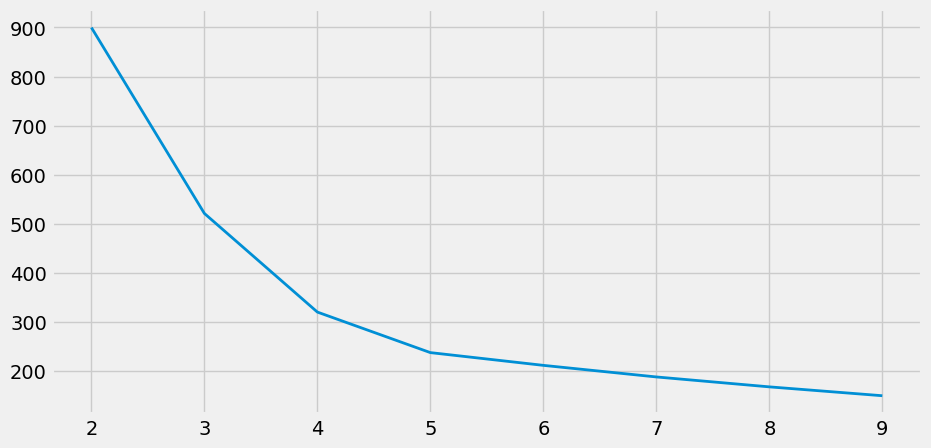

In [158]:
# Plot inertia
plt.figure(figsize=(10, 5))
plt.plot(k_values, inertia)
plt.show()

> NOTE: With the elbow method, `n_clusters=5` seems the best for this data.

In [167]:
# Clustering with 5 centeroids
df_subset = df_cluster[cluster_cols]
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
df_cluster['acc_cluster'] = kmeans.fit_predict(df_subset)
df_cluster

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_r_pse,gyro_r_freq_0.0_Hz_ws_14,gyro_r_freq_0.357_Hz_ws_14,gyro_r_freq_0.714_Hz_ws_14,gyro_r_freq_1.071_Hz_ws_14,gyro_r_freq_1.429_Hz_ws_14,gyro_r_freq_1.786_Hz_ws_14,gyro_r_freq_2.143_Hz_ws_14,gyro_r_freq_2.5_Hz_ws_14,acc_cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:07.800,-0.230583,0.920658,-0.227095,-10.707472,-5.021034,15.580872,B,bench,heavy,30,...,0.575207,202.086051,-47.005987,14.461290,-27.989176,-21.905348,20.370726,4.973285,-42.780588,1
2019-01-11 15:08:08.200,-0.075541,0.854894,-0.094507,-17.787623,-7.152388,16.679304,B,bench,heavy,30,...,0.402857,263.504875,-21.498290,-36.012237,1.513836,-8.751616,-47.941311,31.072425,-30.984847,1
2019-01-11 15:08:08.600,-0.039468,0.947898,-0.047164,1.731909,-0.126808,-3.356740,B,bench,heavy,30,...,0.426478,259.569075,-41.806914,-51.432388,-15.707154,8.694112,-18.444969,20.304371,-30.672891,1
2019-01-11 15:08:09.000,-0.059150,0.977806,-0.028934,3.783211,-3.169243,1.531230,B,bench,heavy,30,...,0.565343,250.684663,-34.973024,56.316165,26.854767,-3.744653,62.263606,2.478403,-21.357192,1
2019-01-11 15:08:09.400,-0.041113,0.974376,-0.045494,-1.058395,-1.138698,1.689075,B,bench,heavy,30,...,0.402768,201.620318,-30.695251,23.587084,-12.110573,24.654652,4.843563,-21.697516,-25.130753,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:26.000,0.074270,-0.604968,0.223617,-14.184394,2.238810,6.776253,E,row,medium,90,...,0.354285,325.916536,9.055941,-59.773786,-40.577734,-47.678614,17.517396,-8.804366,-14.963739,4
2019-01-20 17:33:26.400,0.024062,-1.259307,-0.048022,-28.381136,5.409505,13.608197,E,row,medium,90,...,0.219706,372.665086,64.584232,-12.264317,31.256523,7.586488,20.975436,8.091654,16.110142,0
2019-01-20 17:33:26.800,-0.046404,-1.007241,-0.086284,7.975189,-4.872847,0.582400,E,row,medium,90,...,0.246126,315.012902,-15.922139,17.544414,-26.659005,35.376530,-40.124416,-18.775183,-2.018643,0


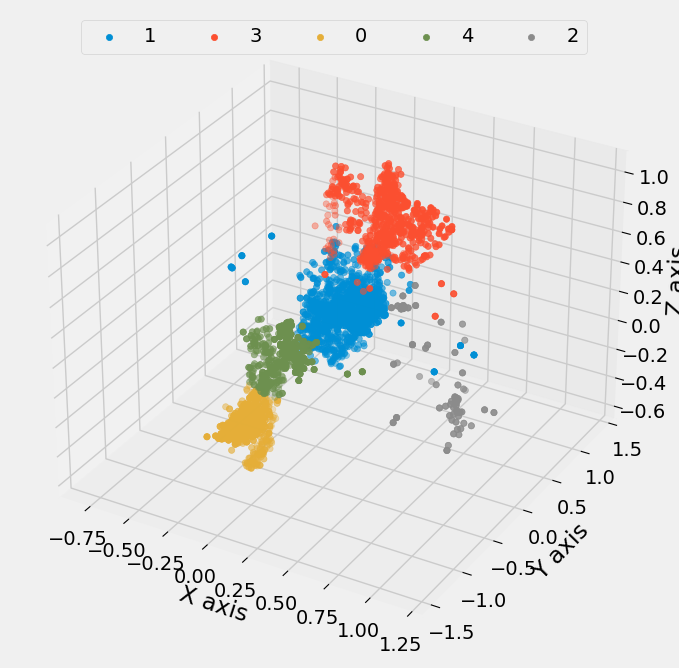

In [194]:
# Plot clusters
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

for c in df_cluster['acc_cluster'].unique():
    df_subset = df_cluster[df_cluster['acc_cluster']==c]
    ax.scatter(df_subset['acc_x'], df_subset['acc_y'], df_subset['acc_z'], label=c)

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.legend(loc='upper center', ncols=5)
plt.show()

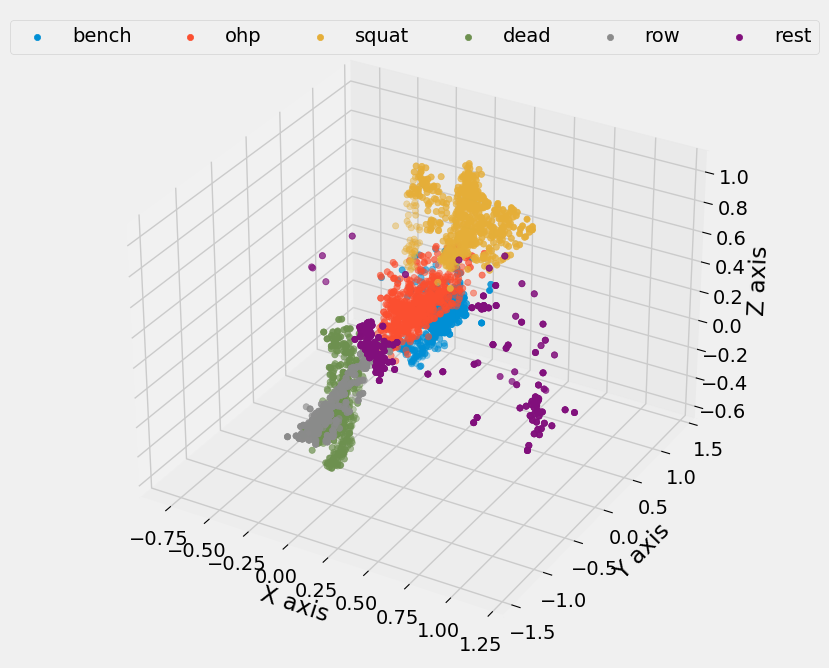

In [201]:
# Plot by exercise
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

for l in df_cluster['label'].unique():
    df_subset = df_cluster[df_cluster['label']==l]
    ax.scatter(df_subset['acc_x'], df_subset['acc_y'], df_subset['acc_z'], label=l)

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.legend(loc='upper center', ncols=6)
plt.show()

> NOTE: The movement of **Bench Press** and **Overhead Press** is quite similar, so is that of **Deadlift** and **Barbell Row**. The movement of Squat is unique and well grouped into a cluster 3. Cosidering the number of clusters is 5 and that of exercise labels is 6, it is expected some exercies are clustered together.

## Export the dataset

In [204]:
df_cluster.to_pickle('../../data/interim/03_features_processed.pkl')